In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder = '/content/drive/MyDrive/Chapman/Research/RADAR/Derek/Analog_Filters/'

Mounted at /content/drive


# old experiment: low and high pass filters

these are the original filters we used for the experiment last year. these include a high pass filter with a cutoff of 100 MHz, a high pass filter with a cutoff of 80 MHz, and a low pass filter with a cutoff of 90 MHz.

it is clear that these do not do a good job of having a flat passband. we discontinued using these for experimentation, but their plots are still here for reference.

In [33]:
csv_files = [
    'sa_unfilt.csv',
    'sa_lp90.csv',
    'sa_hp100.csv',
    'sa_hp80.csv'
]

dataframes = {}

for filepath in csv_files:
    filename = filepath.replace('.csv', '')
    # remove the first 34 rows
    df = pd.read_csv(folder + filepath, skiprows=34, header=None)
    # remove the final six rows
    df = df.iloc[:-6]
    # make both columns floats
    df[0] = df[0].astype(float)
    df[1] = df[1].astype(float)
    # apply a rolling average to smooth out the noise
    df[1] = df[1].rolling(50).mean()
    # the second column is in units of decibels. make a new column in Volts
    df[2] = 10**(df[1]/20)
    # give columns names
    df.rename(columns={0: 'freq', 1: 'dB', 2: 'V'}, inplace=True)
    dataframes[filename] = df

sa_unfilt = dataframes['sa_unfilt']
sa_hp100 = dataframes['sa_hp100']
sa_hp80 = dataframes['sa_hp80']
sa_lp90 = dataframes['sa_lp90']

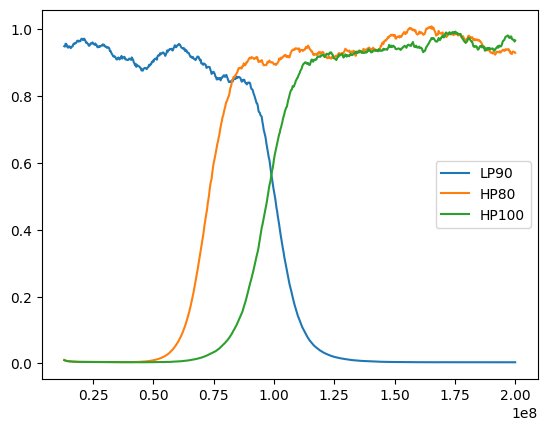

In [36]:
plt.plot(sa_lp90['freq'], sa_lp90['V'] / sa_unfilt['V'], label='LP90')
plt.plot(sa_hp80['freq'], sa_hp80['V'] / sa_unfilt['V'], label='HP80')
plt.plot(sa_hp100['freq'], sa_hp100['V'] / sa_unfilt['V'], label='HP100')
plt.legend()
plt.show()

# new experiment

## wave design for new experiment

for the new experiments, we use a new wave design. it uses four frequencies - if the superoscillating frequency is 1, then the wave's constituent frequencies are 0.3, 0.4, 0.5, and 0.6.

the superoscillating region is designed to replicate 2.5 cycles of a cosine wave. the superoscillations have an amplitude of roughly 1/100 of the total signal's maximum amplitude.

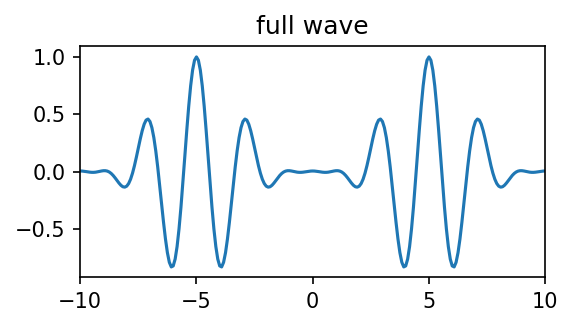

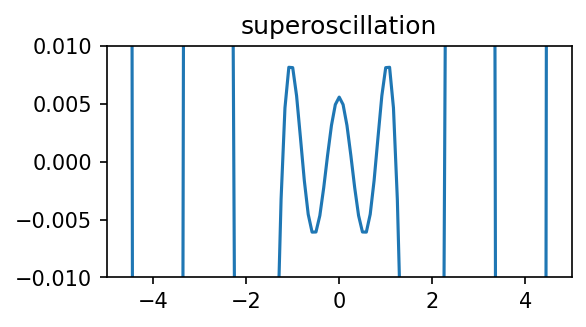

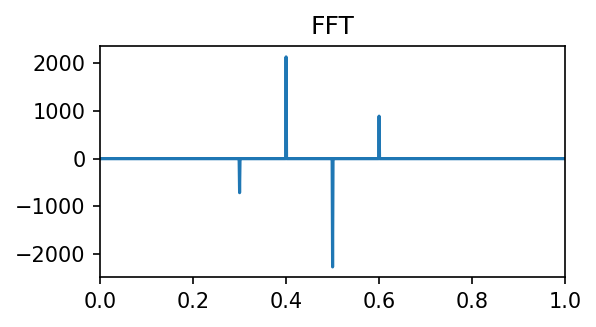

In [70]:
wave    = pd.read_csv(folder + '4peaks_cos.csv', skiprows=4)

plt.rcParams['figure.figsize'] = [4, 2]
plt.rcParams['figure.dpi'] = 150

plt.title('full wave')
plt.plot(wave['Second'], wave['Value'])
plt.xlim(-10, 10)
plt.show()

plt.title('superoscillation')
plt.plot(wave['Second'], wave['Value'])
plt.xlim(-5, 5)
plt.ylim(-.01, .01)
plt.show()

freqs   = np.fft.fftfreq(len(wave['Value']), d=(wave['Second'][1] - wave['Second'][0]))
fft     = np.fft.fft(wave['Value'])

plt.title('FFT')
plt.plot(freqs, np.real(fft))
plt.xlim(0, 1)
plt.show()

the frequencies and their amplitude coefficients used to construct this wave are printed below.

In [69]:
top_8       = np.argsort(np.abs(fft))[::-1][:8]
top_8_locs  = np.argwhere(np.isin(freqs, freqs[top_8]))
top_freqs   = np.real(fft[top_8_locs][:4])

print('frequencies and their coefficients:')
print([float(np.round((i[0]), 2)) for i in freqs[top_8_locs][:4]])
print([float(i[0]/np.max(np.abs(top_freqs))) for i in top_freqs])

frequencies and their coefficients:
[0.3, 0.4, 0.5, 0.6]
[-0.31478314809892577, 0.93822642984254, -1.0, 0.3913961476910592]


## wide band filter for new experiment

here we use a sequence of resistors, capacitors, and inductors to build our own filter, comprised of many (10) notch filters in parallel.

the goal was to make an attenuating region centered around 500 kHz, with a wide stop band, and with a frequency response as flat as possible outside the stop band.

the wide stop band in the frequency domain implies a short impulse response in the time domain. we wanted to test specifically for a short impulse response. if the impulse response could be kept to say, two times the superoscillating frequency, then the impulse response in time should show up over our 2.5 cycles of the superosscillating signal.

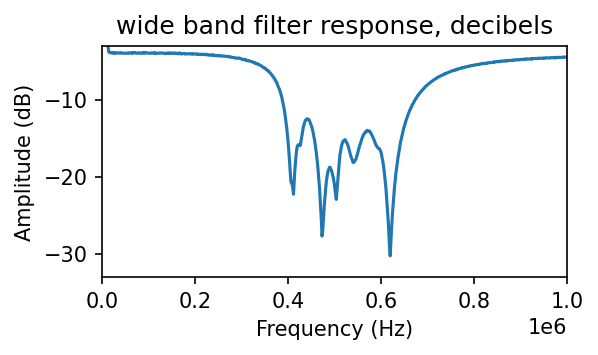

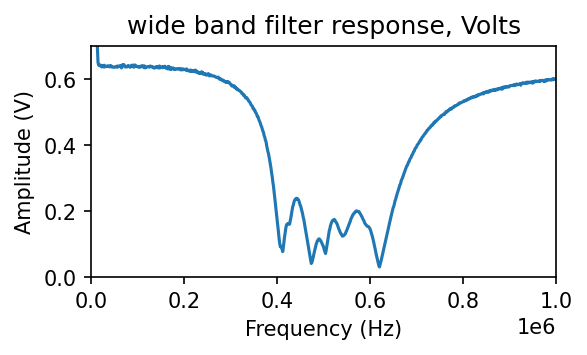

In [43]:
sa_fc2 = pd.read_csv(folder + 'sa_fc2.csv', skiprows=34, header=None)
sa_fc2 = sa_fc2.iloc[:-6]

sa_fc2.rename(columns={0: 'freq', 1: 'dB'}, inplace=True)
sa_fc2['freq']  = sa_fc2['freq'].astype(float)
sa_fc2['dB']    = sa_fc2['dB'].astype(float)
sa_fc2['V']     = 10**(sa_fc2['dB']/20)

plt.title('wide band filter response, decibels')
plt.plot(sa_fc2['freq'], sa_fc2['dB'])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')
plt.xlim(0, 1e6)
plt.ylim(-33, -3)
plt.show()

plt.title('wide band filter response, Volts')
plt.plot(sa_fc2['freq'], sa_fc2['V'])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, 1e6)
plt.ylim(0, .7)
plt.show()

### superoscillations through the filter

we then send our superoscillating signal through the filter to see how severely the superoscillations are distorted.

In [ ]:
fc2_400 = pd.read_csv(folder + 'fc2_400khz1.csv')
tInc    = 1e-9
t       = np.arange(0, len(fc2_400['CH1V']) * tInc, tInc)

fc2_400_fft1    = np.fft.fft(fc2_400['CH1V'])
fc2_400_fft2    = np.fft.fft(fc2_400['CH2V'])
fc2_400_freqs   = np.fft.fftfreq(len(fc2_400['CH1V']), d=tInc)

orange curve indicates a cosine at 400 kHz. while slightly distorted, we can still see that the superoscillations have the same periodicity as the sample cosine.

note that here, the stop band is over 200 kHz while the superoscillating frequency is 400 kHz. this mean's the filter's impulse response is less that two periods of the superoscillating cosine.

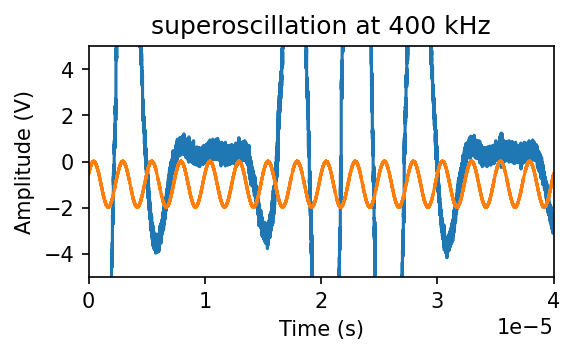

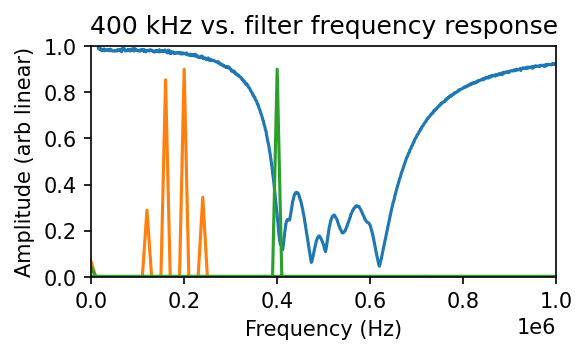

In [ ]:
plt.plot(t, fc2_400['CH1V']*300)
plt.plot(t, fc2_400['CH2V']-1)
plt.title('superoscillation at 400 kHz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, .00004)
plt.ylim(-5, 5)
plt.show()

plt.plot(sa_fc2['freq'], sa_fc2['V']/.65)
plt.plot(fc2_400_freqs, .9*np.abs(fc2_400_fft1)/np.max(np.abs(fc2_400_fft1)))
plt.plot(fc2_400_freqs, .9*np.abs(fc2_400_fft2)/np.max(np.abs(fc2_400_fft2)))
plt.title('400 kHz vs. filter frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (arb linear)')
plt.xlim(0, 1e6)
plt.ylim(0, 1)
plt.show()

In [ ]:
fc2_500 = pd.read_csv(folder + 'fc2_500khz1.csv')

fc2_500_fft1    = np.fft.fft(fc2_500['CH1V'])
fc2_500_fft2    = np.fft.fft(fc2_500['CH2V'])
fc2_500_freqs   = np.fft.fftfreq(len(fc2_500['CH1V']), d=tInc)

now with the superoscillation at 500 kHz. similar to before, the superoscillations still maintain the same periodicity as the cosine, though they are now starting to further distort.

here, the impulse response is an even larger multiple of the superoscillating period, but we see more distortion in the superoscillation rather than less.

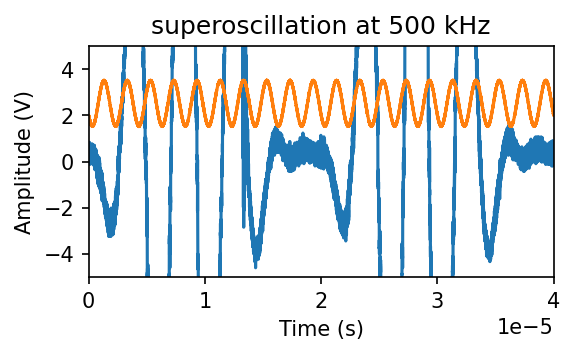

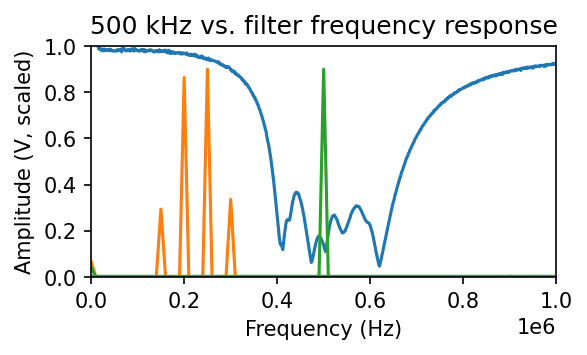

In [ ]:
plt.plot(t, fc2_500['CH1V']*300)
plt.plot(t, fc2_500['CH2V']+2.5)
plt.title('superoscillation at 500 kHz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, 4e-5)
plt.ylim(-5, 5)
plt.show()

plt.plot(sa_fc2['freq'], sa_fc2['V']/.65)
plt.plot(fc2_500_freqs, .9*np.abs(fc2_500_fft1)/np.max(np.abs(fc2_500_fft1)))
plt.plot(fc2_500_freqs, .9*np.abs(fc2_500_fft2)/np.max(np.abs(fc2_500_fft2)))
plt.title('500 kHz vs. filter frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V, scaled)')
plt.xlim(0, 1e6)
plt.ylim(0, 1)
plt.show()

## notch filter for new experiment

here we focus on a filter that has a very narrow frequency response, a very long impulse response, and a much flatter passband. this was created by use of a single notch filter - one resistor, one capacitor, and one inductor.

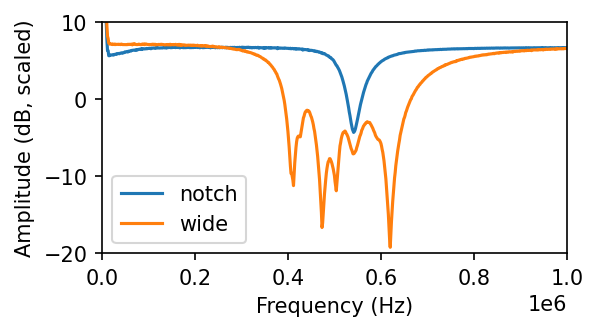

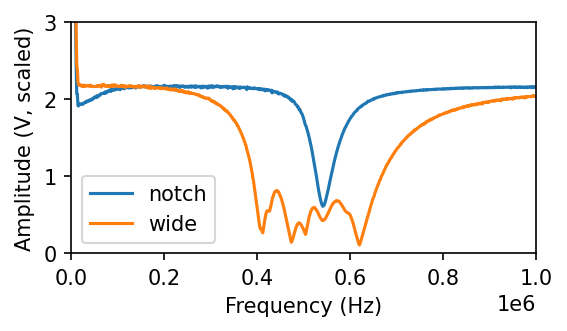

In [ ]:
sa_notch = pd.read_csv(folder + 'sa_notch.csv', skiprows=34, header=None)
sa_notch = sa_notch.iloc[:-6]

sa_notch.rename(columns={0: 'freq', 1: 'dB'}, inplace=True)
sa_notch['freq']  = sa_notch['freq'].astype(float)
sa_notch['dB']    = sa_notch['dB'].astype(float)
sa_notch['V']     = 10**(sa_notch['dB']/20)

plt.plot(sa_notch['freq'], sa_notch['dB'], label='notch')
plt.plot(sa_fc2['freq'], sa_fc2['dB']+11, label='wide')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB, scaled)')
plt.legend()
plt.xlim(0, 1e6)
plt.ylim(-20, 10)
plt.show()

plt.plot(sa_notch['freq'], sa_notch['V'], label='notch')
plt.plot(sa_fc2['freq'], sa_fc2['V']*3.4, label='wide')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V, scaled)')
plt.legend()
plt.xlim(0, 1e6)
plt.ylim(0, 3)
plt.show()

### superoscillations through the filter

In [ ]:
notch_400 = pd.read_csv(folder + 'notch_400khz1.csv')
notch_500 = pd.read_csv(folder + 'notch_500khz1.csv')
notch_600 = pd.read_csv(folder + 'notch_600khz0.csv')
notch_800 = pd.read_csv(folder + 'notch_800khz0.csv')

notch_400_freqs = np.fft.fftfreq(len(notch_400['CH1V']), d=tInc)
notch_500_freqs = np.fft.fftfreq(len(notch_500['CH1V']), d=tInc)
notch_600_freqs = np.fft.fftfreq(len(notch_600['CH1V']), d=tInc)
notch_800_freqs = np.fft.fftfreq(len(notch_800['CH1V']), d=tInc)

notch_400_fft1 = np.fft.fft(notch_400['CH1V'])
notch_400_fft2 = np.fft.fft(notch_400['CH2V'])
notch_500_fft1 = np.fft.fft(notch_500['CH1V'])
notch_500_fft2 = np.fft.fft(notch_500['CH2V'])
notch_600_fft1 = np.fft.fft(notch_600['CH1V'])
notch_600_fft2 = np.fft.fft(notch_600['CH2V'])
notch_800_fft1 = np.fft.fft(notch_800['CH1V'])
notch_800_fft2 = np.fft.fft(notch_800['CH2V'])

at 400 kHz superoscillation through the notch filter, we see a much more faithful preservation of the superoscillating shape than we could achieve through the wide band filter.

500 kHz and 600 kHz superoscillations are also preserved with great accuracy. it is not until 800 kHz, when the constituent frequencies of the total signal are significantly attenuated, that we see destruction of the superoscillations in time.

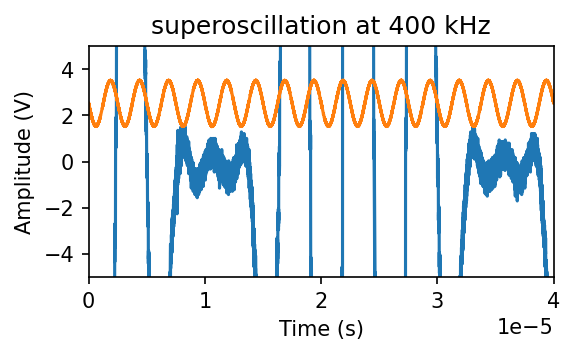

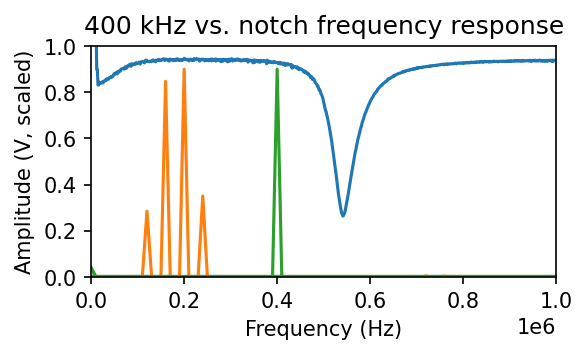

In [ ]:
plt.plot(t, notch_400['CH1V']*300-1)
plt.plot(t, notch_400['CH2V']+2.5)
plt.title('superoscillation at 400 kHz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, .00004)
plt.ylim(-5, 5)
plt.show()

plt.plot(sa_notch['freq'], sa_notch['V']/2.3)
plt.plot(notch_400_freqs, .9*np.abs(notch_400_fft1)/np.max(np.abs(notch_400_fft1)))
plt.plot(notch_400_freqs, .9*np.abs(notch_400_fft2)/np.max(np.abs(notch_400_fft2)))
plt.title('400 kHz vs. notch frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V, scaled)')
plt.xlim(0, 1e6)
plt.ylim(0, 1)
plt.show()

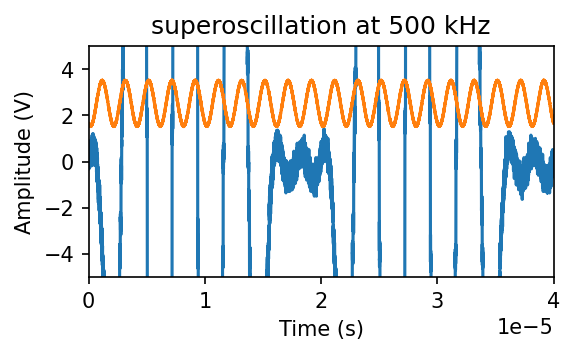

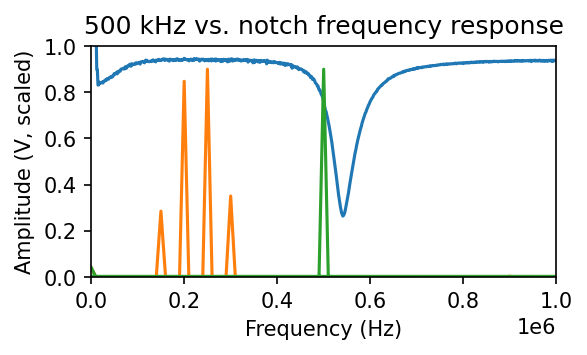

In [ ]:
plt.plot(t, notch_500['CH1V']*300-1)
plt.plot(t, notch_500['CH2V']+2.5)
plt.title('superoscillation at 500 kHz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, .00004)
plt.ylim(-5, 5)
plt.show()

plt.plot(sa_notch['freq'], sa_notch['V']/2.3)
plt.plot(notch_500_freqs, .9*np.abs(notch_500_fft1)/np.max(np.abs(notch_500_fft1)))
plt.plot(notch_500_freqs, .9*np.abs(notch_500_fft2)/np.max(np.abs(notch_500_fft2)))
plt.title('500 kHz vs. notch frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V, scaled)')
plt.xlim(0, 1e6)
plt.ylim(0, 1)
plt.show()

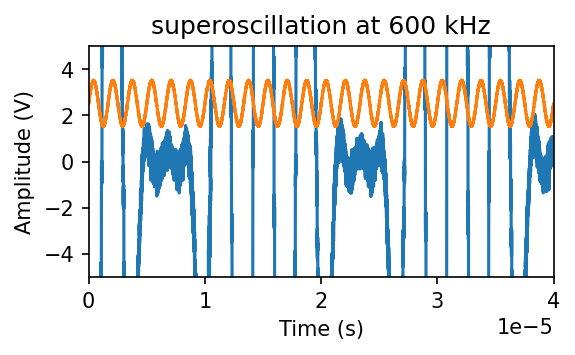

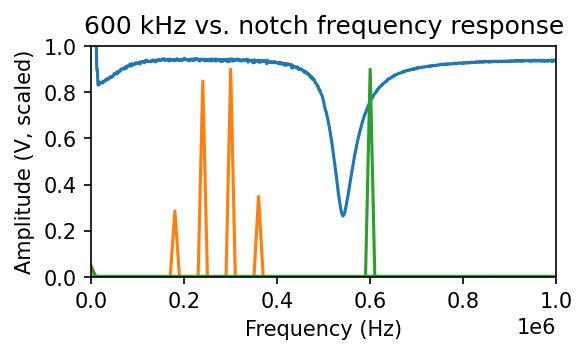

In [ ]:
plt.plot(t, notch_600['CH1V']*300-1)
plt.plot(t, notch_600['CH2V']+2.5)
plt.title('superoscillation at 600 kHz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, .00004)
plt.ylim(-5, 5)
plt.show()

plt.plot(sa_notch['freq'], sa_notch['V']/2.3)
plt.plot(notch_600_freqs, .9*np.abs(notch_600_fft1)/np.max(np.abs(notch_600_fft1)))
plt.plot(notch_600_freqs, .9*np.abs(notch_600_fft2)/np.max(np.abs(notch_600_fft2)))
plt.title('600 kHz vs. notch frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V, scaled)')
plt.xlim(0, 1e6)
plt.ylim(0, 1)
plt.show()

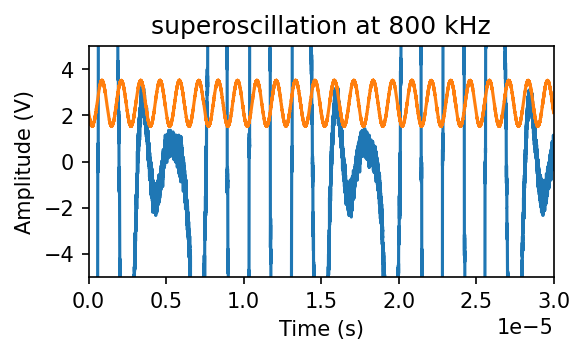

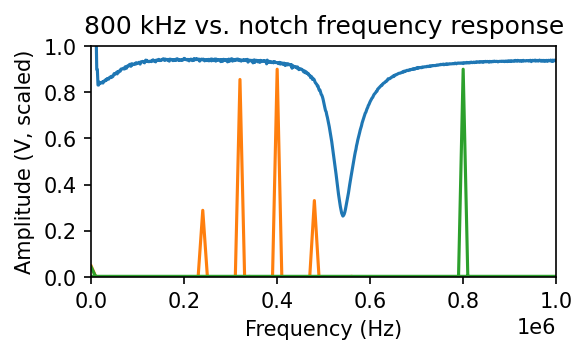

In [ ]:
plt.plot(t, notch_800['CH1V']*300-1)
plt.plot(t, notch_800['CH2V']+2.5)
plt.title('superoscillation at 800 kHz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, .00003)
plt.ylim(-5, 5)
plt.show()

plt.plot(sa_notch['freq'], sa_notch['V']/2.3)
plt.plot(notch_800_freqs, .9*np.abs(notch_800_fft1)/np.max(np.abs(notch_800_fft1)))
plt.plot(notch_800_freqs, .9*np.abs(notch_800_fft2)/np.max(np.abs(notch_800_fft2)))
plt.title('800 kHz vs. notch frequency response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V, scaled)')
plt.xlim(0, 1e6)
plt.ylim(0, 1)
plt.show()

# conclusions

it seems that the filter's width of frequency response does not matter, nor does its impulse response width. all that matters is the attenuation of the signal's constituent frequencies.